This project analyzes customer churn and identifies key drivers of retention, along with actionable strategies to improve engagement.

In [4]:
import pandas as pd
df=pd.read_csv("Bank Customer Churn Prediction.csv")

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df.shape

(10000, 12)

In [7]:
# Engagement vs Churn
pd.crosstab(df['active_member'], df['churn'], normalize=True)

churn,0,1
active_member,,
0,0.3547,0.1302
1,0.4416,0.0735


Observed: Higher churn proportion among inactive members (~13%) compared to active members,i.e. ~7%.

Indicating: Customer engagement strongly reduces churn probability

Hence recommending: Increase engagement via app usage, transactions, notifications, loyalty programs

In [41]:
#Product Usage vs Churn
pd.crosstab(df['products_number'], df['churn'], normalize='index')

churn,0,1
products_number,,
1,0.722856,0.277144
2,0.924183,0.075817
3,0.172932,0.827068
4,0.000000,1.000000


Observed: Customers with 1 product show moderate churn proportion, while customers with 2 products show lowest churn. But there is a spike in churn as number of products cross 2.

Indicating: Moderate product adoption (2 products) improves retention, but higher number of products (3–4) may again increase churn (possible dissatisfaction/complexity)

Hence recommending:
Cross-sell customers from 1 → 2 products
Investigate why 3+ product users churn (over-selling? poor experience?)

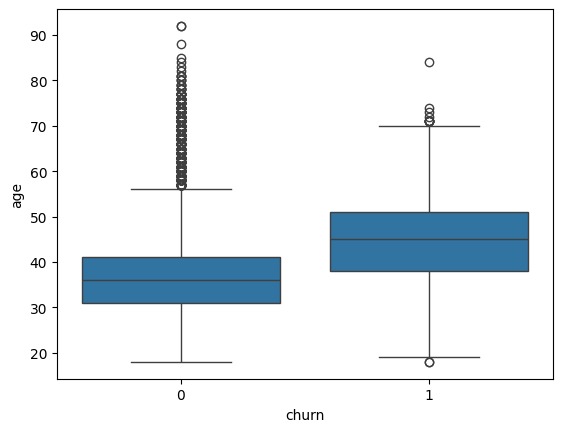

In [11]:
#Age vs Churn
sns.boxplot(x='churn', y='age', data=df)
plt.show()

Observed: Median age of churned customers is higher than non-churned customers

Indicating: Older customers are more likely to churn compared to younger customers

Hence recommending:
Target retention strategies for older customers
Provide personalized financial products / relationship management

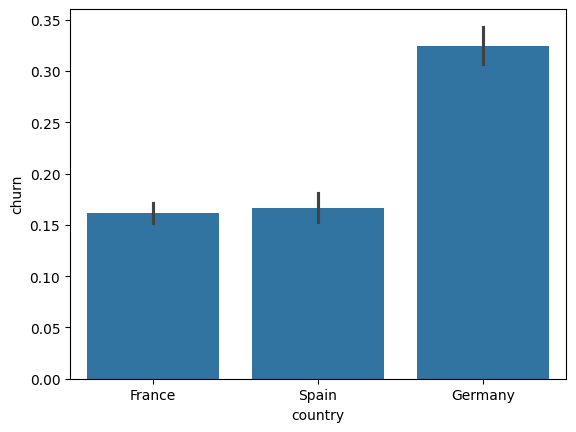

In [44]:
#Country vs Churn
sns.barplot(x='country', y='churn', data=df)
plt.show()

Observed: Customers from Germany show significantly higher churn rate compared to France and Spain

Indicating: Possible regional dissatisfaction or competitive pressure
Hence recommending:

Investigate Germany-specific issues (pricing, service, competitors)
Launch targeted retention campaigns in Germany

In [48]:
#Combined Driver Analysis
df.groupby(['products_number', 'active_member'])['churn'].agg(['mean','count'])

mean  count
products_number active_member                 
1               0              0.366521   2521
                1              0.189231   2563
2               0              0.098881   2144
                1              0.055601   2446
3               0              0.882353    153
                1              0.752212    113
4               0              1.000000     31
                1              1.000000     29

Churn appears extremely high for customers with 3 or more products, these insights are not reliable due to small sample sizes and should not be used for decision-making

Customer Segmentation:
- At-risk users: inactive + 1 product  
- Loyal users: active + 2 products  
- High-risk users: older + inactive  
- Growth opportunity: active users with only 1 product  

Key Recommendations:
- Increase engagement through notifications and product nudges  
- Encourage adoption of a second product  
- Target older and inactive users with personalized strategies  
- Investigate high-churn regions for potential issues  

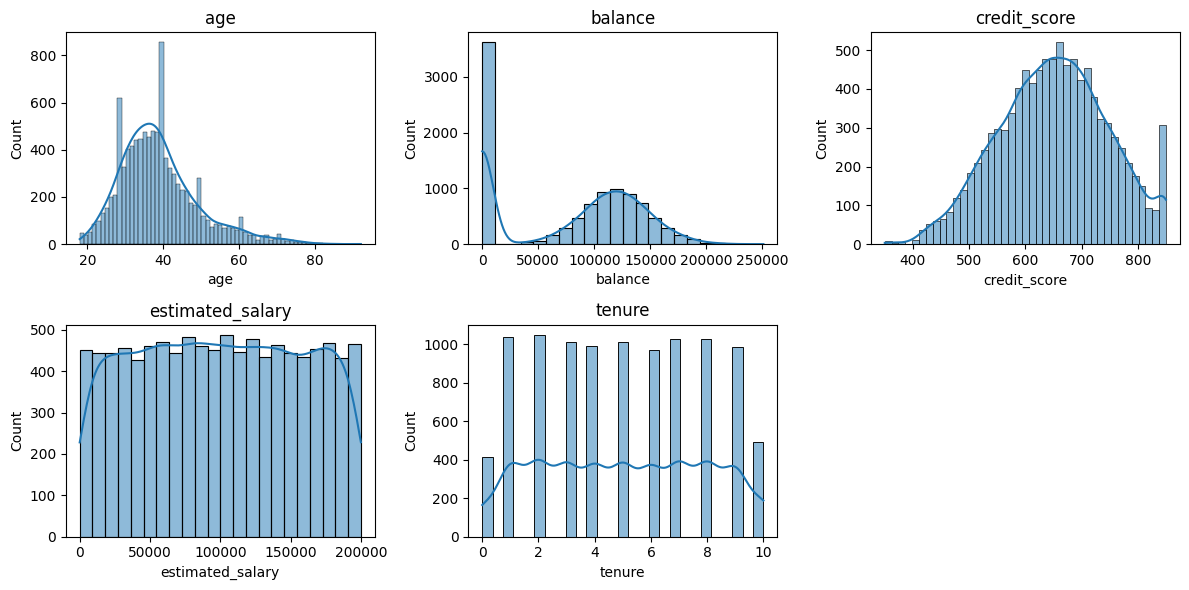

In [39]:
#Additional Explorations
measures = ['age','balance','credit_score','estimated_salary','tenure']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(measures):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)


fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

1. Age: right skewed distribution, can target and identify causes of churn age-group wise

2. Balance: Many customers have zero balance, excluding that, its roughly normally distributed

3. Credit score: roughly normal, limit is likely to be 850

4. Estimated salary: Roughly Uniform, could be grouped with dimensions if needed

5. Tenure:Roughly Uniform, could be grouped with dimensions if needed


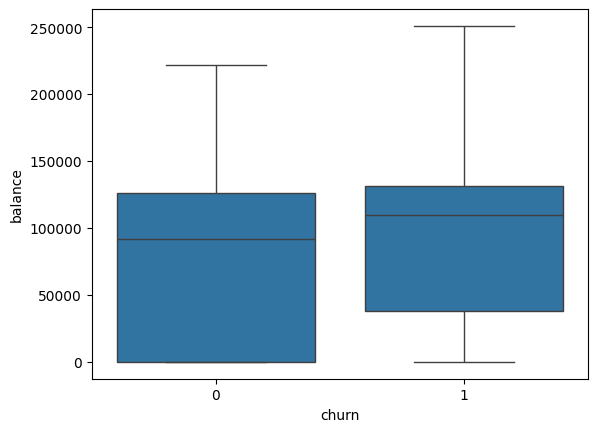

In [42]:
sns.boxplot(x='churn',y='balance',data=df)
plt.show()

Observed: Churned customers tend to have slightly higher median balances, while many non-churned customers have zero balance

Indicating: Balance alone is not a strong predictor; zero-balance customers distort interpretation

Hence recommending:
Segment customers: zero vs non-zero balance
Analyze churn separately for both groups

In [45]:
pd.crosstab(df['credit_card'], df['churn'], normalize='index')

churn,0,1
credit_card,,
0,0.791851,0.208149
1,0.798157,0.201843


Observed: Minimal difference in churn between groups

Indicating: Credit card status has negligible impact

Hence recommending: Ignore or deprioritize this variable unless combined with others

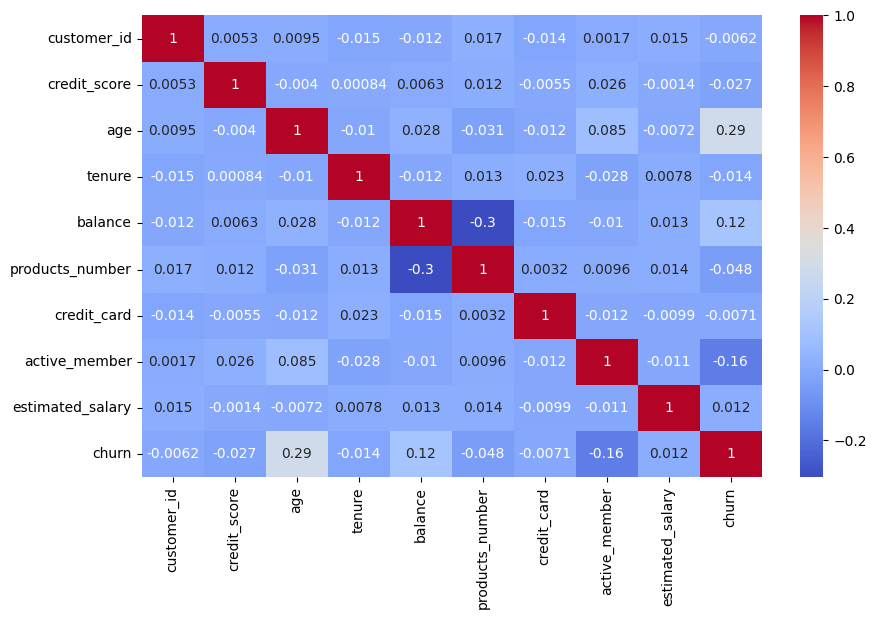

In [46]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Significant correlation with churn is shown by *age,balance,active_member*.

*Product_number* and *credit_score* could also be combined with relevant columns to identify possible reasons of churning.


In [47]:
df.groupby(['products_number', 'active_member'])['churn'].mean()

products_number  active_member
1                0                0.366521
                 1                0.189231
2                0                0.098881
                 1                0.055601
3                0                0.882353
                 1                0.752212
4                0                1.000000
                 1                1.000000
Name: churn, dtype: float64

Observed:
Churn decreases from 1 → 2 products
Active members always have lower churn than inactive
Very high churn for 3 and 4 products

Indicating:
Having 2 products is associated with lowest churn
Active membership consistently reduces churn
Extreme churn values for 3+ products may be due to low sample size

Hence recommending:
Get more data for 3+ products so that it could be validated.

In [49]:
df.groupby(['active_member', pd.cut(df['age'], bins=[18,30,45,60,100])])['churn'].agg(['mean','count'])

/tmp/ipykernel_5291/2217345226.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['active_member', pd.cut(df['age'], bins=[18,30,45,60,100])])['churn'].agg(['mean','count'])


mean  count
active_member age                       
0             (18, 30]   0.101784    953
              (30, 45]   0.197277   3011
              (45, 60]   0.683609    787
              (60, 100]  0.820225     89
1             (18, 30]   0.049345    993
              (30, 45]   0.116151   2910
              (45, 60]   0.353488    860
              (60, 100]  0.112000    375

Observed:
Churn increases with age for inactive members
Active members have lower churn in every age group
Big drop in churn for active vs inactive in older groups due to older groups

Indicating:
Age effect exists, but activity modifies it strongly
Being active reduces churn across all age segments

Hence Recommended: Key focus on increasing engagement across all age groups. Churn appears very low for customers in (60,80] age bin, but these insights are not reliable due to small sample sizes and should not be used for decision-making

In [50]:
df.groupby(pd.qcut(df['estimated_salary'], 5))['churn'].mean()

/tmp/ipykernel_5291/2658557425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['estimated_salary'], 5))['churn'].mean()


,churn
estimated_salary,
"(11.579, 41050.736]",0.1995
"(41050.736, 80238.34]",0.1995
"(80238.34, 119710.038]",0.2020
"(119710.038, 159836.726]",0.2020
"(159836.726, 199992.48]",0.2155


In [51]:
df.groupby(pd.qcut(df['credit_score'], 5))['churn'].mean()

/tmp/ipykernel_5291/3819172161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['credit_score'], 5))['churn'].mean()


,churn
credit_score,
"(349.999, 566.0]",0.224876
"(566.0, 627.0]",0.208416
"(627.0, 678.0]",0.196517
"(678.0, 735.0]",0.183241
"(735.0, 850.0]",0.205154


In [52]:
df.groupby(['country', 'active_member'])['churn'].mean()

country  active_member
France   0                0.211308
         1                0.115014
Germany  0                0.410785
         1                0.237179
Spain    0                0.233476
         1                0.107470
Name: churn, dtype: float64

Observed:
Germany has highest churn in both active & inactive
Active members always have lower churn than inactive

Indicating:
Country differences exist
Activity reduces churn consistently across countries

Hence recommending:
Germany needs deeper investigation
Activity is a stable protective factor

In [54]:
df.groupby(['active_member','products_number', pd.cut(df['age'], bins=[18,30,45,60,100], right=False)])['churn'].agg(['mean','count'])

/tmp/ipykernel_5291/3770952107.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['active_member','products_number', pd.cut(df['age'], bins=[18,30,45,60,100], right=False)])['churn'].agg(['mean','count'])


mean  count
active_member products_number age                       
0             1               [18, 30)   0.150838    358
                              [30, 45)   0.249169   1505
                              [45, 60)   0.735849    583
                              [60, 100)  0.880000     75
              2               [18, 30)   0.032483    431
                              [30, 45)   0.069013   1449
                              [45, 60)   0.334728    239
                              [60, 100)  0.720000     25
              3               [18, 30)   0.714286     14
                              [30, 45)   0.815789     76
                              [45, 60)   1.000000     52
                              [60, 100)  1.000000     11
              4               [18, 30)   1.000000      1
                              [30, 45)   1.000000     13
                              [45, 60)   1.000000     17
                              [60, 100)       NaN      0
1             1               [18, 30)   0.070529    397
                              [30, 45)   0.144828   1450
                              [45, 60)   0.422925    506
                              [60, 100)  0.157143    210
              2               [18, 30)   0.025701    428
                              [30, 45)   0.039781   1458
                              [45, 60)   0.152589    367
                              [60, 100)  0.056995    193
              3               [18, 30)   0.500000     12
                              [30, 45)   0.690909     55
                              [45, 60)   0.973684     38
                              [60, 100)  0.500000      8
              4               [18, 30)        NaN      0
                              [30, 45)   1.000000     13
                              [45, 60)   1.000000     12
                              [60, 100)  1.000000      4

Observed: Across large and reliable segments, churn is highest among customers with a single product, increases with age (especially after 45), and is consistently lower for active members. Customers with two products show significantly lower churn across all age groups.

Indicating: Product ownership and customer activity are the strongest drivers of churn, while age amplifies risk but is secondary to behavior.

Hence recommending: Focus on cross-selling a second product and improving customer engagement, especially for older inactive users who form the highest-risk segment.